## Students

* Ettore Vissa (2187527)
* Sara Pasquato (2198446)
* Enrica Calabretto (2198447)
* Nicolo' Meneguzzo 

# Gradient descent & Deep Neural Networks

We can build the neural network using `Sequential()` class  from Keras, called model, that allows building the NN layer by layer. We add 3 `Dense()` hidden layers each consisting of 20 neurons on top of an input layer, and lastly we add an output layer.

In [8]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib as mpl
import matplotlib.pyplot as plt
import keras_tuner as kt
from tensorflow.keras import optimizers
from sklearn.model_selection import KFold
from keras.callbacks import EarlyStopping

# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler


np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

%run useful.py



## Read data

8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1


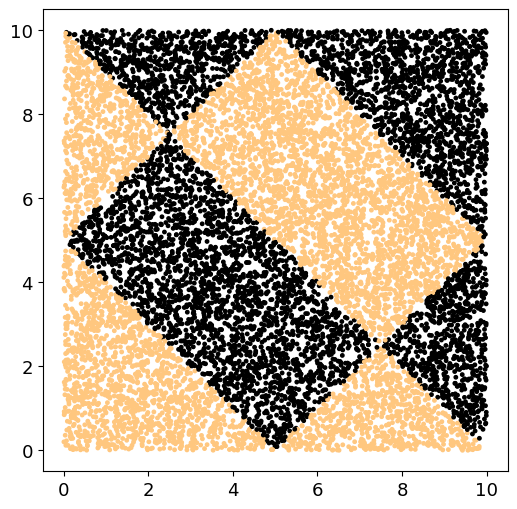

In [9]:
TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")


# dim. of a sample ( possibile da togliere) 
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])



plot_data(x,y)

## Prepare Data ( with standardization) 

In [10]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

def prepare_data(x,y):
    """
    Does rescaling, and divides the input data into training and test set.
    """
    perc_train=0.8
    
    N=len(x)
    N_train = int(perc_train * N)

    x_mean = np.mean(x,axis=0)
    x_std  = np.std(x,axis=0)
    
    x = Standardize(x,x_mean,x_std)
    
    (x_train, y_train) = (x[0:N_train],y[0:N_train])
    (x_test, y_test) = (x[N_train:],y[N_train:])
    return x_train,y_train, x_test,y_test

In [11]:
x_train_valid, y_train_valid, x_test, y_test= prepare_data( x, y) 
x_train= x_train_valid[200:] 
y_train= y_train_valid[200:]

x_valid= x_train_valid[:200] 
y_valid=y_train_valid[:200]

## 1) Random Search of best hyperparameters

For the first step we define the model and its architecture. Here we implement a random search using "Keras Tuner" package. 
We optimized the following hyper-parameters searching through the associated options:

* Optimizer: {Adam, SGD with Nesterov momentum, RMSprop}
* Non-linear activation function: {sigmoid, ReLU, ELU}
* Dropout value: {$0.0, 0.1, 0.2$}
* Learning rate: {$10^{-6}$, $10^{-5}$, $10^{-4}$, $10^{-3}$, $10^{-2}$, $10^{-1}$ }

In [12]:
def build_model_tuning(hp):
    model = Sequential()
    activation_choice = hp.Choice('activation', values=['relu', 'elu', 'sigmoid'])
    droput_choice = hp.Choice('dropout', values=[0.0, 0.1, 0.2])
    lr_choice = hp.Choice('learning_rate', values=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'nesterov'])


    model.add(Dense(L,input_shape=(L,),activation=activation_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    
    model.add(Dense(1,activation='sigmoid'))
   

    # Set the optimizer to vary the learning rate
    if optimizer_choice == 'adam':
        opt = optimizers.Adam(learning_rate=lr_choice)
    elif optimizer_choice == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=lr_choice)
    elif optimizer_choice == 'nesterov':
        opt = optimizers.SGD(learning_rate=lr_choice, momentum=0.9, nesterov=True)
        
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    
    return model


### Random search of the best models

In [13]:
# tuner definition
tuner = kt.RandomSearch(
    build_model_tuning,
    objective='val_accuracy',
    max_trials=15, # we try 15 combinations
    executions_per_trial=1,
    project_name='search', 
    overwrite=True 
)

stop_early= EarlyStopping(patience= 5) 
tuner.search(x_train, y_train, epochs=400, validation_data=(x_valid, y_valid), verbose=0, callbacks= [stop_early])


#print the best 4 configurations
tuner.results_summary( num_trials= 4)


top_hp = tuner.get_best_hyperparameters(num_trials=4) 

Results summary
Results in ./search
Showing 4 best trials
Objective(name="val_accuracy", direction="max")

Trial 09 summary
Hyperparameters:
activation: relu
dropout: 0.0
learning_rate: 0.0001
optimizer: rmsprop
Score: 0.9800000190734863

Trial 05 summary
Hyperparameters:
activation: sigmoid
dropout: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.9700000286102295

Trial 08 summary
Hyperparameters:
activation: relu
dropout: 0.2
learning_rate: 0.001
optimizer: nesterov
Score: 0.9700000286102295

Trial 02 summary
Hyperparameters:
activation: elu
dropout: 0.1
learning_rate: 0.001
optimizer: nesterov
Score: 0.9649999737739563


In [14]:
models = tuner.get_best_models(num_models=4)

/home/ettore/anaconda3/envs/LCPB_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ettore/anaconda3/envs/LCPB_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ettore/anaconda3/envs/LCPB_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Cross Validation
We perform a K-fold cross validation to compare and select the best model over the chosen ones.

In [15]:
def k_fold_cross_validation(x_train, y_train, k, models):
    # Initialize holders
    rng = np.random.default_rng(1758)
    best = -1 # Best model
    best_perf = -1 # Best score
    results = [] # List to store performance of each model
    histories = []
    # Divide training set in K folds
    idx = rng.permutation(np.arange(x_train.shape[0]))
    x_folds, y_folds = np.array_split(x_train[idx, :], k), np.array_split(y_train[idx], k)
    
    for i in range(len(models)):
        model_perf = []  # Stores each k-th score
        for test in range(k):
            # Define validation and training set
            x_train_fold = np.concatenate([x for i, x in enumerate(x_folds) if i != test])
            y_train_fold = np.concatenate([x for i, x in enumerate(y_folds) if i != test])
            x_validate_fold, y_validate_fold = x_folds[test], y_folds[test]
            k_model = tuner.hypermodel.build(top_hp[i])
            k_model.fit(x_train_fold, y_train_fold, epochs=400, verbose=0, validation_data=(x_validate_fold, y_validate_fold), callbacks=EarlyStopping(patience=5))
            # Accumulates the performance
            model_perf.append(k_model.evaluate(x_validate_fold, y_validate_fold, verbose=0)[1])        
        results.append(((curr_perf := np.mean(model_perf)), np.std(model_perf))) # Average and std over the k-folds
        # if the current model performs better than best, updates best__
        if (best_perf < curr_perf): best, best_perf = models[i], curr_perf
        #Below: return best model, its index, and list of performance results for each model
    return best, results

best_model, results = k_fold_cross_validation(x_train_valid, y_train_valid, 5, models)
print(results) #Performance of each model.


[(np.float64(0.9799999952316284), np.float64(0.002411618030448404)), (np.float64(0.7386458337306976), np.float64(0.1946315605976607)), (np.float64(0.8712499856948852), np.float64(0.16936020567166793)), (np.float64(0.8666666626930237), np.float64(0.183464676194917))]


In [16]:
def train_data(x_train,y_train,x_valid,y_valid):
    '''
    Fits train and test set using the best model found above, and plots the relative scores.
    '''
    nepoch = 400
    fit = best_model.fit(x_train, y_train,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=0)
    
    fig,AX=plt.subplots(1,2,figsize=(12,5.), layout='constrained')
    ax=AX[0]
    ax.plot(fit.history['accuracy'],label="train",c="b", lw=0.7)
    ax.plot(fit.history['val_accuracy'],label="valid",c="r", lw=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel("Accuracy")
    ax.set_xlim(0,400)
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b", lw=0.7)
    ax.plot(fit.history['val_loss'],label="valid",c="r", lw=0.7)
    ax.set_xlabel('Epoch')
    ax.set_xlim(0,400)
    ax.set_ylabel("Loss")
    ax.legend()


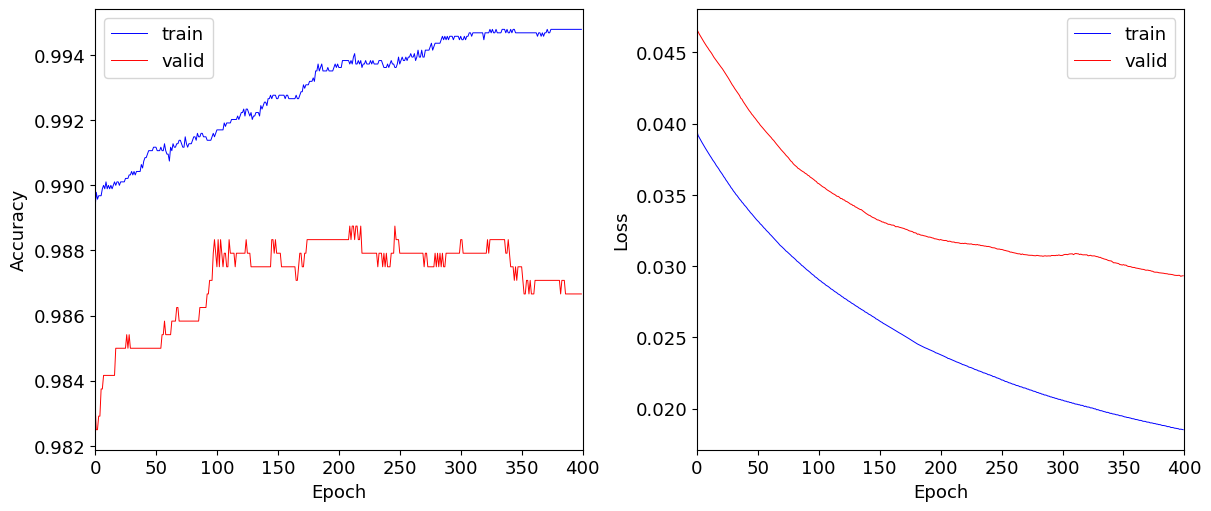

In [17]:
train_data(x_train, y_train, x_test, y_test)

In [18]:
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.0293
Final test accuracy: 0.9867


## Grid to show the prediction

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step


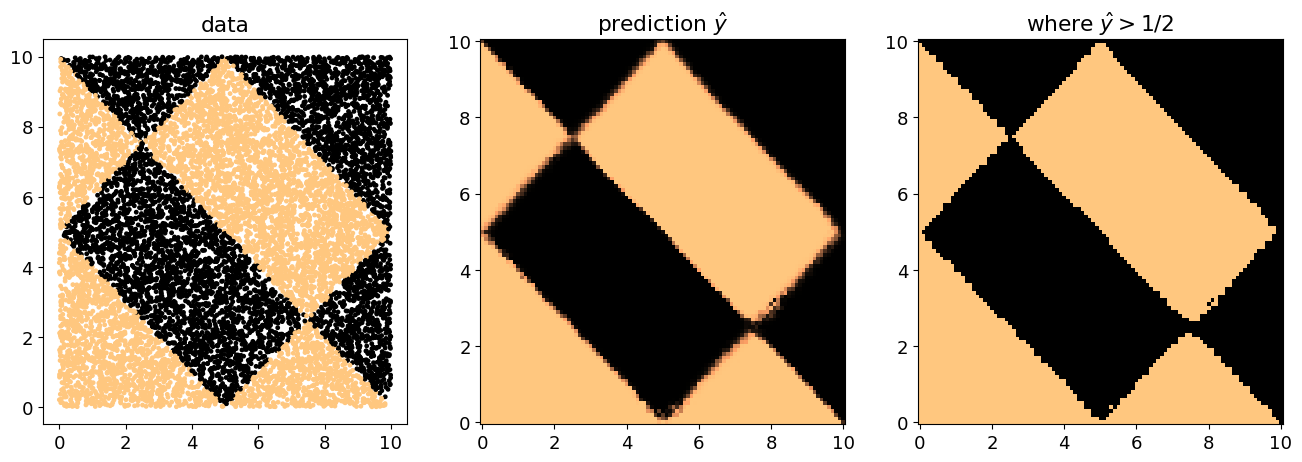

In [19]:
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_mean,x_std)

pred = best_model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()


# 2) Reduction and Augmentation

## Reduction

In the following, we test the best model obtained from the k-fold cross-validation for different values of 
N (1000, 3000, 6000, 9000, 12000).\
For each value of N, we show a plot of the accuracy and loss during the training and validation phases. In addition, we display the prediction grid produced by the model.

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step


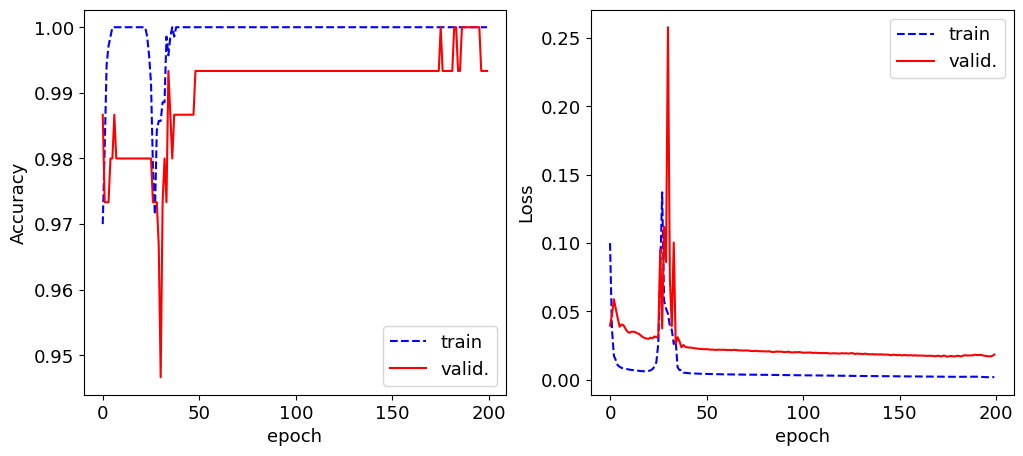

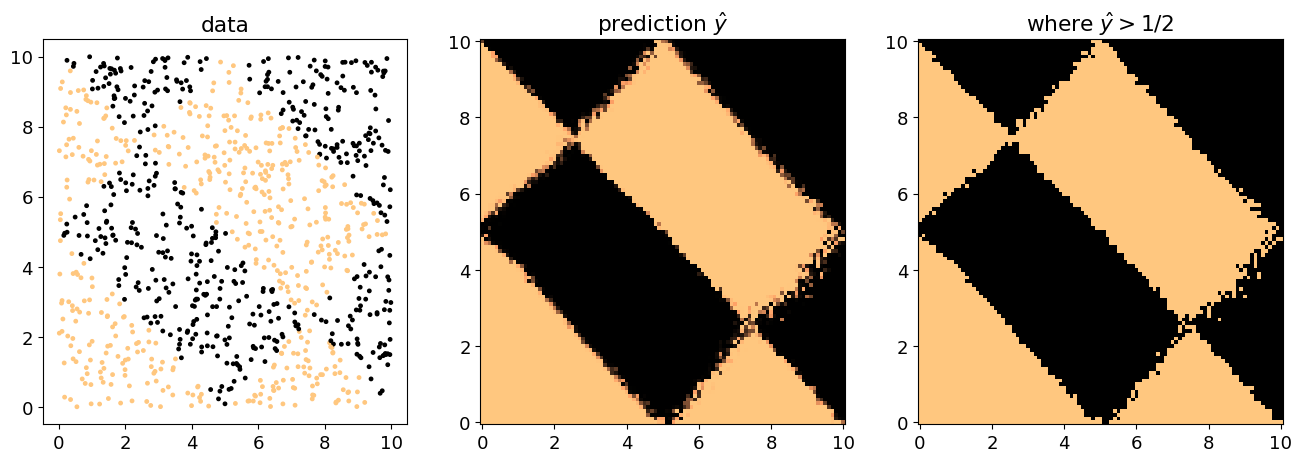

test_accuracy for N = 1000: 0.8933333158493042
test_loss for N = 1000: 0.658004641532898
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step


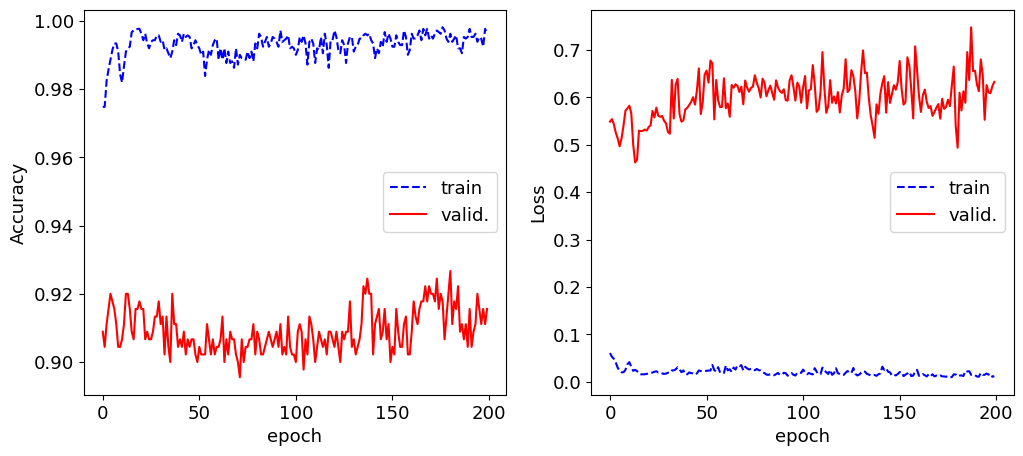

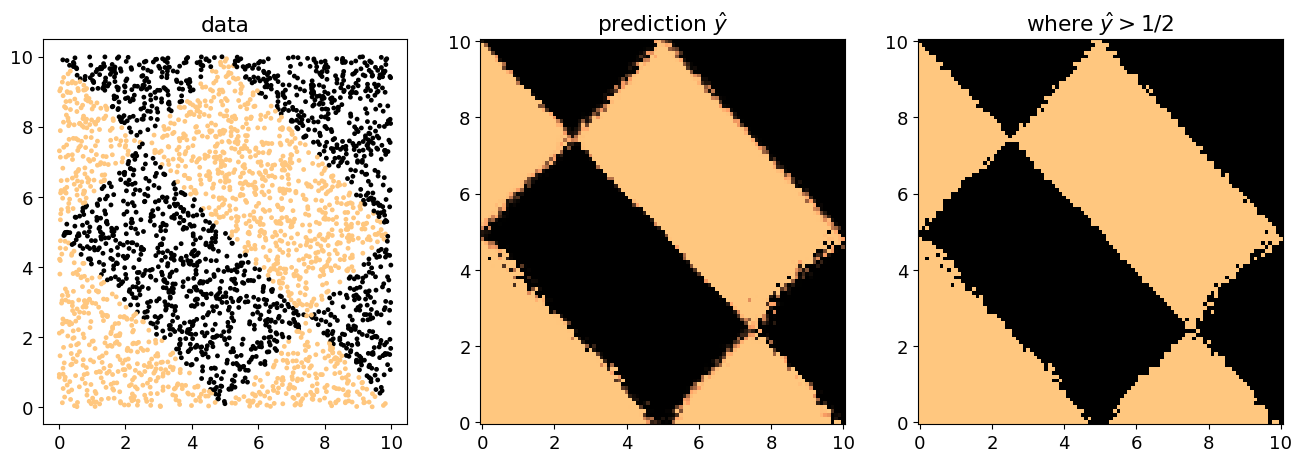

test_accuracy for N = 3000: 0.9644444584846497
test_loss for N = 3000: 0.11533087491989136
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step


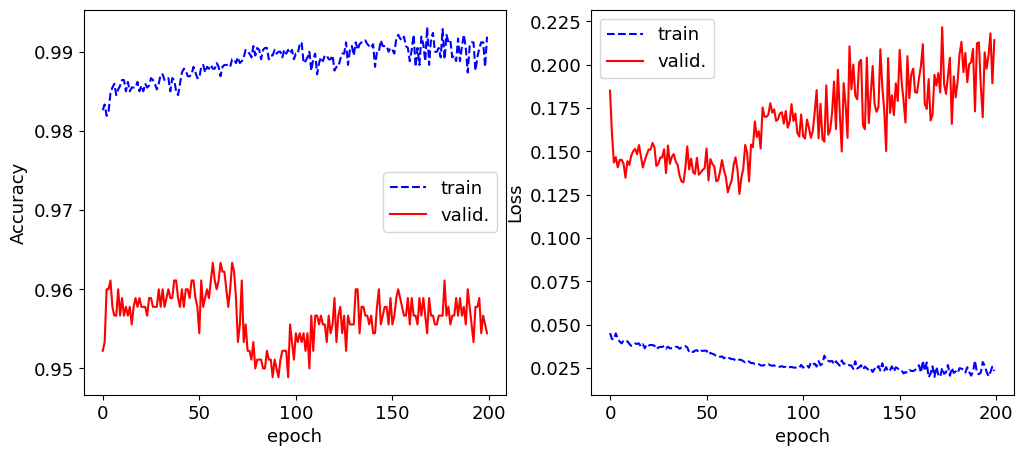

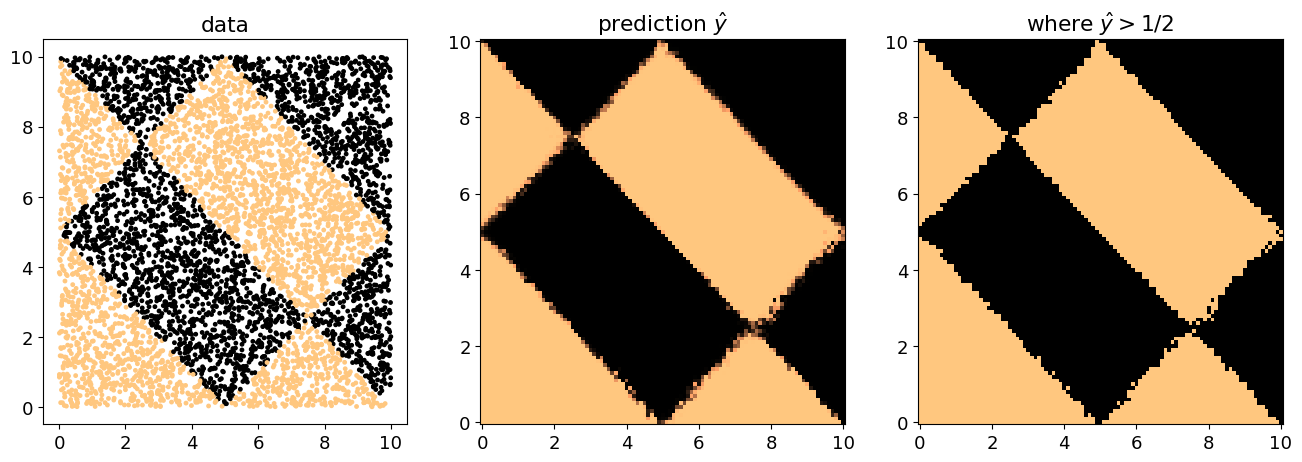

test_accuracy for N = 6000: 0.95333331823349
test_loss for N = 6000: 0.19984708726406097
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step


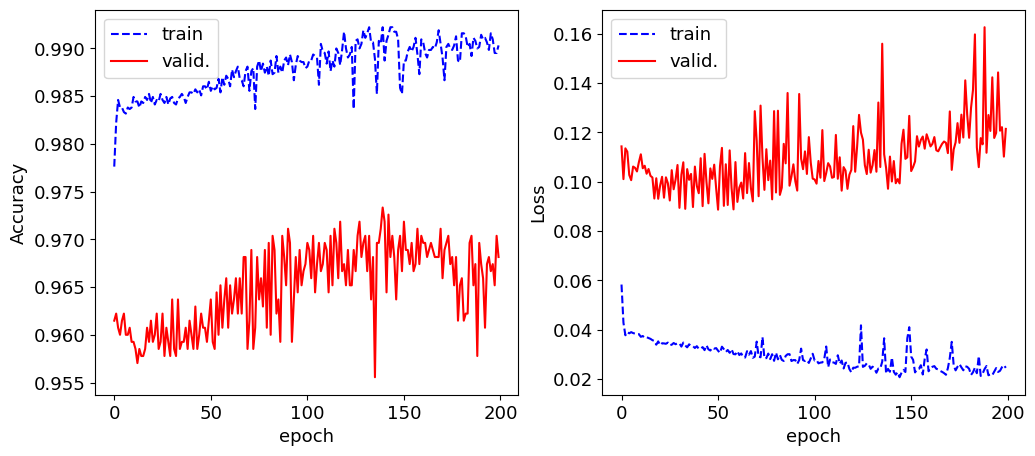

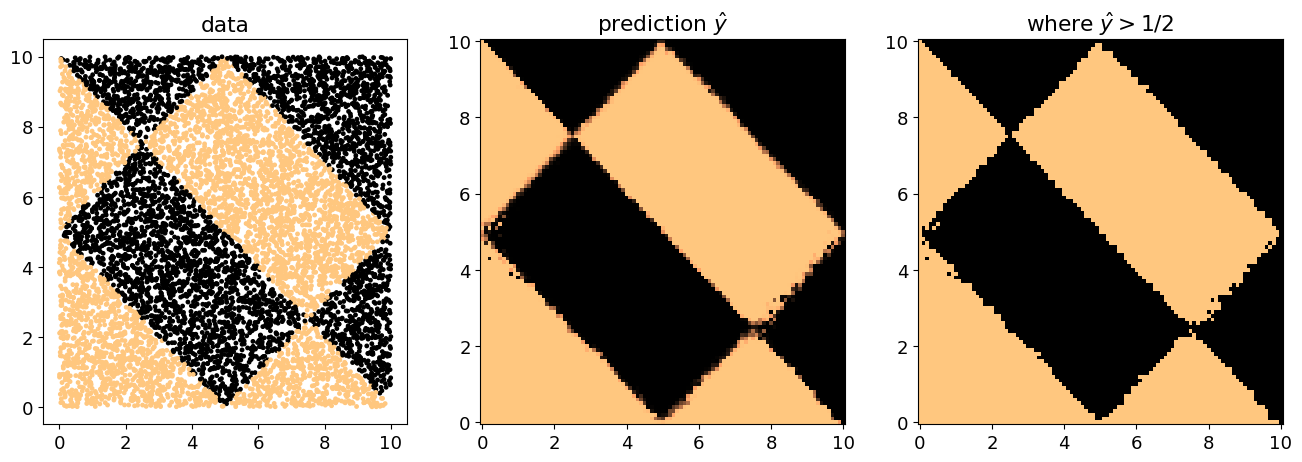

test_accuracy for N = 9000: 0.9711111187934875
test_loss for N = 9000: 0.2039622664451599
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step


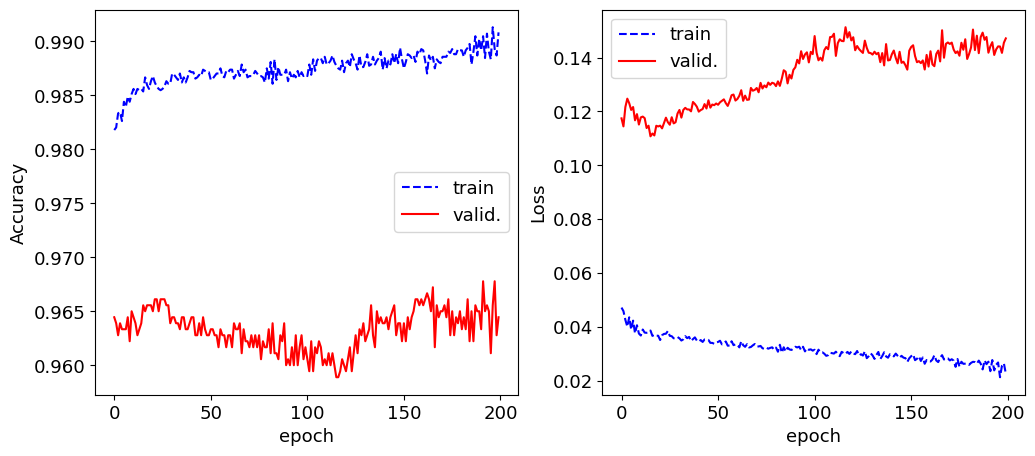

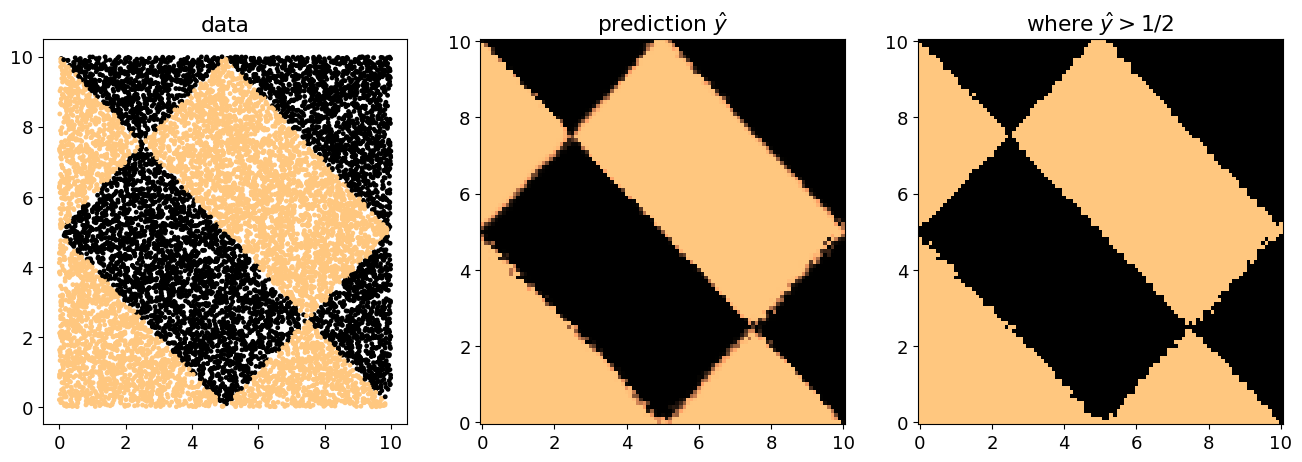

test_accuracy for N = 12000: 0.9627777934074402
test_loss for N = 12000: 0.14802008867263794


In [20]:
import tensorflow as tf

N_red_list=[1000,3000,6000,9000,12000]
test_accuracy_list=[]
test_loss_list=[]
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15

initial_weights = best_model.get_weights()


for N_red in N_red_list:
    
    model = tf.keras.models.clone_model(best_model)
    model.set_weights(initial_weights)  
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
    indices = np.random.choice(len(x), N_red, replace=False)
    x_red = x[indices]
    y_red = y[indices]
    N_train_red = int(perc_train * N_red)
    N_valid_red = int(perc_valid * N_red)
    N_test_red = N_red - N_train_red - N_valid_red
 
    (x_train_red, y_train_red) = (x_red[0:N_train_red],y_red[0:N_train_red])
    (x_valid_red, y_valid_red) = (x_red[N_train_red:N_train_red+N_valid_red],y_red[N_train_red:N_train_red+N_valid_red])
    (x_test_red, y_test_red) = (x_red[N_train_red+N_valid_red:],y_red[N_train_red+N_valid_red:])
    
    x_train_mean_red = np.mean(x_train_red, axis=0)
    x_train_std_red = np.std(x_train_red, axis=0)
    x_valid_mean_red = np.mean(x_valid_red, axis=0)
    x_valid_std_red = np.std(x_valid_red, axis=0)
    x_test_mean_red = np.mean(x_test_red, axis=0)
    x_test_std_red = np.std(x_test_red, axis=0)
    x_train_red = Standardize(x_train_red, x_train_mean_red, x_train_std_red)
    x_valid_red = Standardize(x_valid_red, x_valid_mean_red, x_valid_std_red)
    x_test_red = Standardize(x_test_red, x_test_mean_red, x_test_std_red)
    np.random.seed(12345)
    
    fit = model.fit(x_train_red, y_train_red,epochs = 200, batch_size = 50,validation_data=(x_valid_red,y_valid_red),
                verbose=0)
    
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0]
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()
    
    
    dX = .1
    X1 = np.arange(0,10+dX, dX)
    LG = len(X1)
    # 2D meshgrid
    X, Y = np.meshgrid(X1, X1)
    allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
    #create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
    grid = np.random.rand(LG**2,L)*B
    #replace first 2 features with the actual 2D coordinates
    grid[:,:2] = allXY
    #standardize using train-set mean/std before prediction
    grid_r_red=Standardize(grid,x_train_mean_red,x_train_std_red)

    pred = model.predict(grid_r_red)

    fig,AX=plt.subplots(1,3,figsize=(16,5.))
    ax=AX[0]
    ax.scatter(x_red[:,0],x_red[:,1],c=y_red,s=6)
    ax.set_title("data")
    ax=AX[1]
    ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
    ax.set_title("prediction $\\hat y$")
    ax=AX[2]
    pred01=np.copy(pred)
    pred01[pred>0.5]=1
    pred01[pred<=0.5]=0
    ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
    ax.set_title("where $\\hat y > 1/2$")
    plt.show()
    
    test_loss, test_acc = model.evaluate(x_test_red, y_test_red, verbose=0)
    
    test_accuracy_list.append(test_acc)
    test_loss_list.append(test_loss)
    print(f'test_accuracy for N = {N_red}: {test_acc}')
    print(f'test_loss for N = {N_red}: {test_loss}')

    

In the following plot, the values of the loss and accuracy are shown as a function of N.

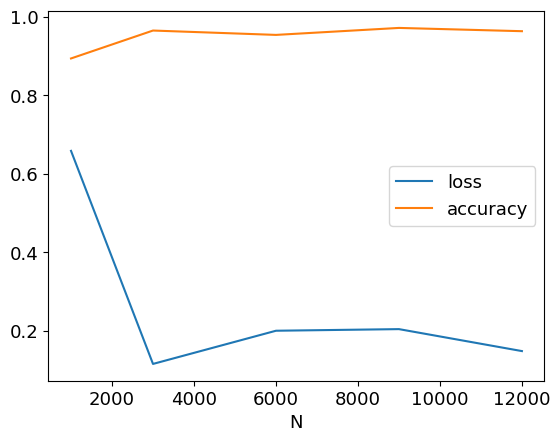

In [21]:
plt.plot(N_red_list,test_loss_list,label="loss")
plt.plot(N_red_list,test_accuracy_list,label="accuracy")
plt.xlabel("N")
plt.legend()

# Augmentation

In the following, we evaluate the best model obtained from the k-fold cross-validation for different values of σ (0.1, 0.3, 0.5), where 
σ denotes the standard deviation of the Gaussian noise added to the data. For each value of σ, we report the training and validation accuracy and loss, and we also display the corresponding prediction grid.

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step


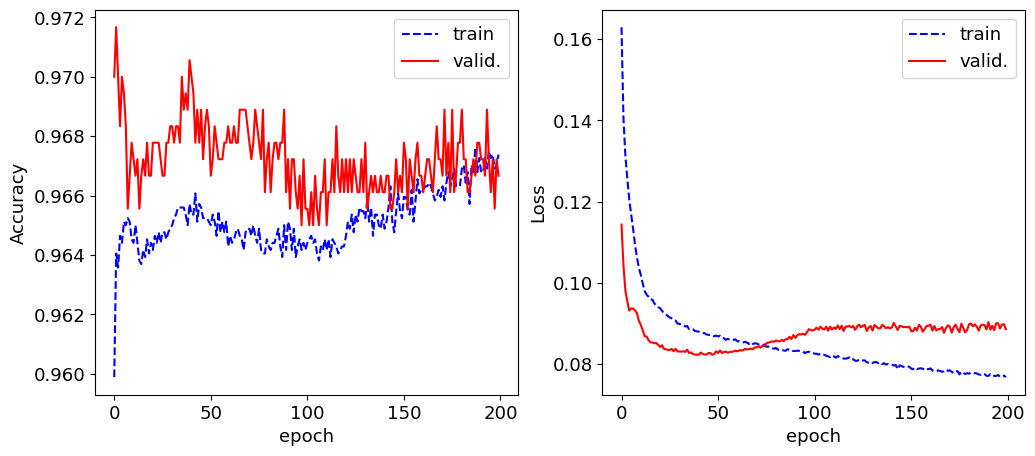

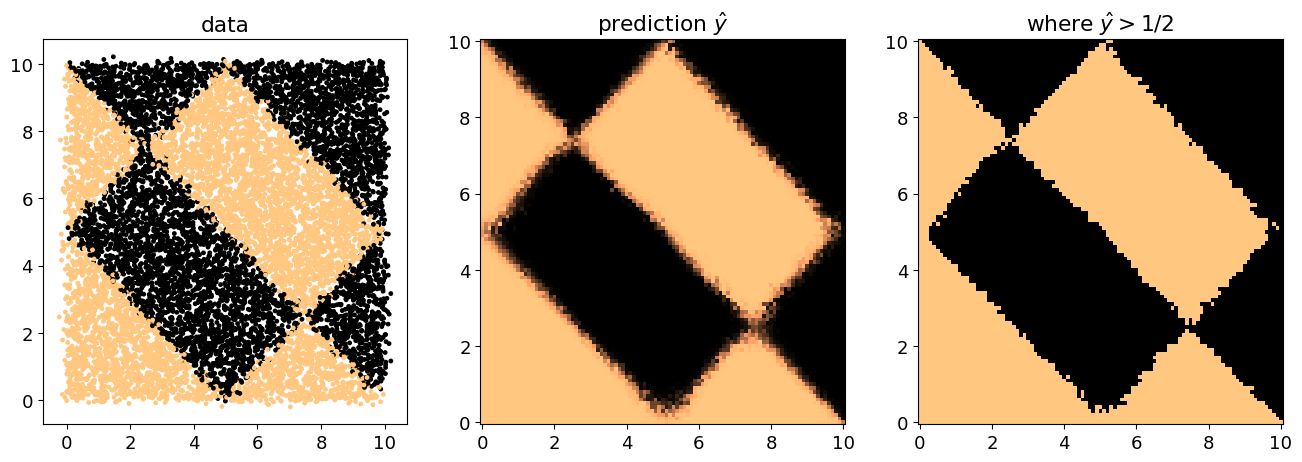

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step


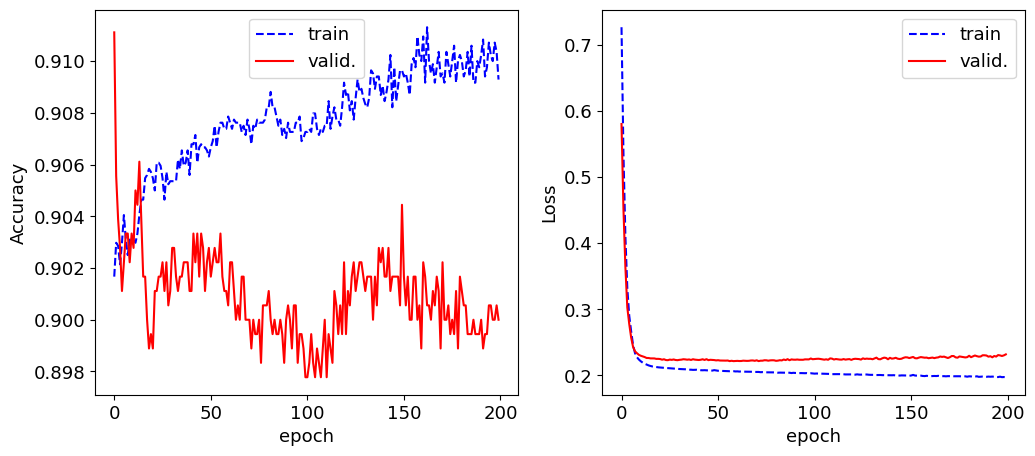

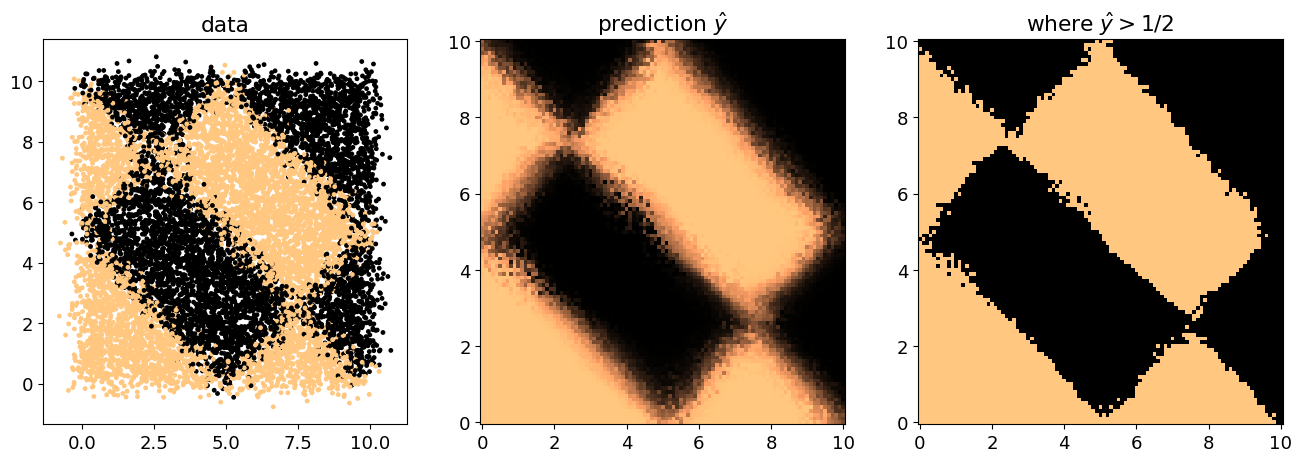

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step


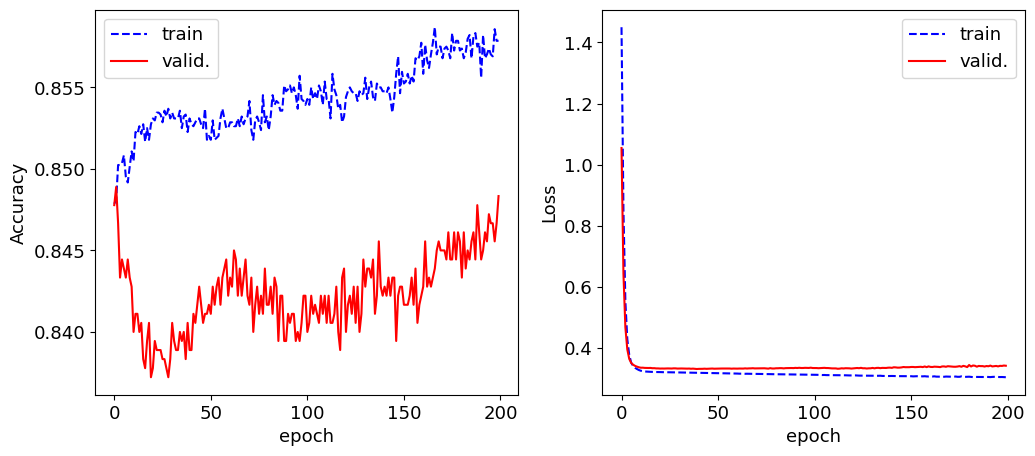

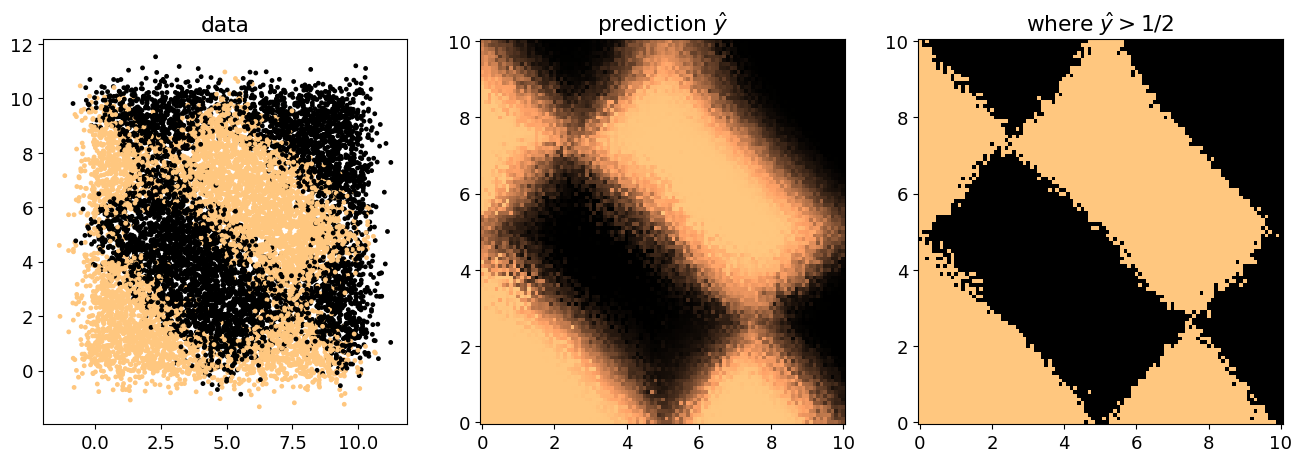

test_accuracy:  [0.9505555629730225, 0.8916666507720947, 0.8427777886390686]
test_loss:  [0.11875509470701218, 0.24717232584953308, 0.35161474347114563]


In [22]:
sigma_list=[0.1,0.3,0.5]
test_accuracy_list2=[]
test_loss_list2=[]

initial_weights = best_model.get_weights()

for sigma in sigma_list:
    
    model = tf.keras.models.clone_model(best_model)
    model.set_weights(initial_weights)  
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
    x_aug=x+np.random.normal(0,sigma,size=(len(y),8))
    N = len(x_aug)

    N_train = int(perc_train * N)
    N_valid= int(perc_valid * N)
    N_test = N - N_train - N_valid
    (x_train_aug, y_train) = (x_aug[0:N_train],y[0:N_train])
    (x_valid_aug, y_valid) = (x_aug[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
    (x_test_aug, y_test) = (x_aug[N_train+N_valid:],y[N_train+N_valid:])
    x_train_mean_aug = np.mean(x_train_aug, axis=0)
    x_train_std_aug = np.std(x_train_aug, axis=0)
    x_valid_mean_aug = np.mean(x_valid_aug, axis=0)
    x_valid_std_aug = np.std(x_valid_aug, axis=0)
    x_test_mean_aug = np.mean(x_test_aug, axis=0)
    x_test_std_aug = np.std(x_test_aug, axis=0)
    x_train_aug = Standardize(x_train_aug, x_train_mean_aug, x_train_std_aug)
    x_valid_aug = Standardize(x_valid_aug, x_valid_mean_aug, x_valid_std_aug)
    x_test_aug = Standardize(x_test_aug, x_test_mean_aug, x_test_std_aug)
    np.random.seed(12345)
    
    fit_aug = model.fit(x_train_aug, y_train,epochs = 200, batch_size = 50,validation_data=(x_valid_aug,y_valid),
                verbose=0)
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0]
    ax.plot(fit_aug.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit_aug.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit_aug.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit_aug.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()

    dX = .1
    X1 = np.arange(0,10+dX, dX)
    LG = len(X1)
    # 2D meshgrid
    X, Y = np.meshgrid(X1, X1)
    allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
    #create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
    grid = np.random.rand(LG**2,L)*B
    #replace first 2 features with the actual 2D coordinates
    grid[:,:2] = allXY
    #standardize using train-set mean/std before prediction
    grid_r_aug=Standardize(grid,x_train_mean_aug,x_train_std_aug)

    pred_aug = model.predict(grid_r_aug)

    fig,AX=plt.subplots(1,3,figsize=(16,5.))
    ax=AX[0]
    ax.scatter(x_aug[:,0],x_aug[:,1],c=y,s=6)
    ax.set_title("data")
    ax=AX[1]
    ax.pcolormesh(X1,X1,pred_aug.reshape((LG, LG)))
    ax.set_title("prediction $\\hat y$")
    ax=AX[2]
    pred01=np.copy(pred_aug)
    pred01[pred_aug>0.5]=1
    pred01[pred_aug<=0.5]=0
    ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
    ax.set_title("where $\\hat y > 1/2$")
    plt.show()
    
    test_loss, test_acc = model.evaluate(x_test_aug, y_test, verbose=0)
    
    test_accuracy_list2.append(test_acc)
    test_loss_list2.append(test_loss)
print('test_accuracy: ',test_accuracy_list2)
print('test_loss: ',test_loss_list2)


In the following plot, the values of the loss and accuracy are shown as a function of N.

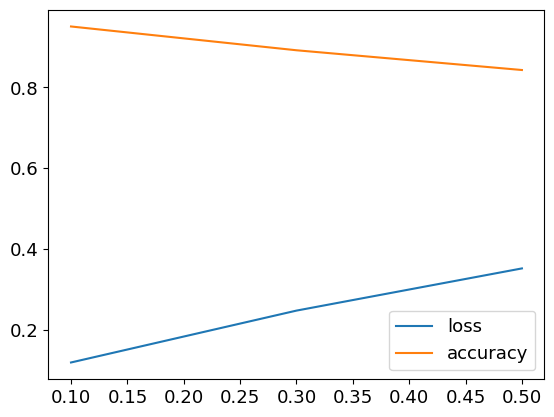

In [23]:
plt.plot(sigma_list,test_loss_list2,label="loss")
plt.plot(sigma_list,test_accuracy_list2,label="accuracy")
plt.legend()